"""
HEPSIM GSoC 2026 Evaluation — Quark/Gluon Jet Classification
Author: Binoy Saha | University of Texas at Arlington

This notebook analyzes the Pythia8 Quark and Gluon Jets dataset to explore
the fundamental differences between quark and gluon initiated jets. We compute
jet observables (mass, width, pT dispersion), perform a Lorentz boost to the
jet rest frame, and build a neural network classifier to distinguish quark from
gluon jets using rest-frame features. Key finding: gluon jets are broader and
more diffuse than quark jets due to the larger color charge of gluons (Casimir
factor CA=3 vs CF=4/3), making them systematically harder to reconstruct cleanly.
"""

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('dark_background')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All dependencies loaded successfully")
print(f"NumPy: {np.__version__} | PyTorch: {torch.__version__}")

All dependencies loaded successfully
NumPy: 2.4.3 | PyTorch: 2.10.0


Loaded QG_jets.npz: 100000 jets, max multiplicity 139
Loaded QG_jets_1.npz: 100000 jets, max multiplicity 134

Total jets loaded: 200000
Feature shape: (200000, 139, 4)  →  (jets, max_constituents, [pT, rapidity, phi, pdgid])
Quark jets: 100000  |  Gluon jets: 100000
Total constituents in quark jets: 3,335,323
Total constituents in gluon jets: 5,320,182
Average constituents per quark jet: 33.4
Average constituents per gluon jet: 53.2

Physics note: Gluon jets have more constituents on average —
gluons carry larger color charge (CA=3 vs CF=4/3) causing more fragmentation


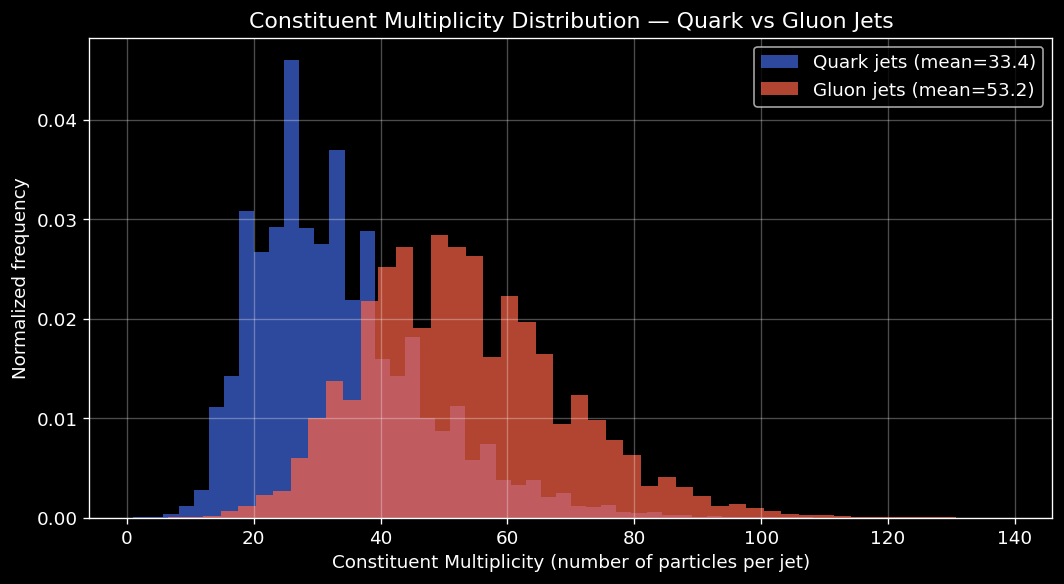


Quark jet multiplicity — mean: 33.4, std: 13.3
Gluon jet multiplicity — mean: 53.2, std: 15.8


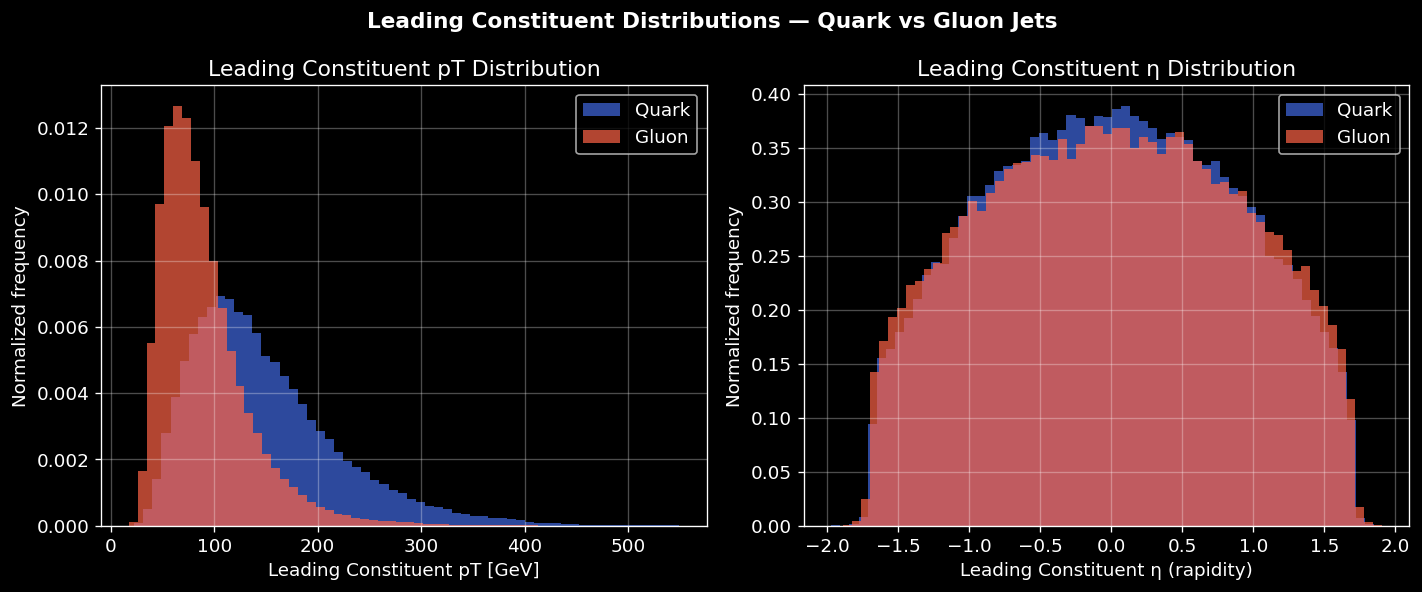

In [10]:
#Part A - Data Loading and exploration

def load_jet_data(filepaths):
    """
    Load and concatenate jet data from multiple .npz files.
    Handles zero-padding by masking constituents with pT = 0.
    Pads files to common max multiplicity before concatenating.
    
    Returns:
        X: (N, max_constituents, 4) array of constituent features [pT, y, phi, pdgid]
        y: (N,) binary labels — 0=gluon, 1=quark
    """
    X_list, y_list = [], []
    for path in filepaths:
        data = np.load(path)
        X_list.append(data['X'])
        y_list.append(data['y'])
        print(f"Loaded {path}: {data['X'].shape[0]} jets, max multiplicity {data['X'].shape[1]}")
    
    # Find the largest multiplicity across all files
    max_mult = max(x.shape[1] for x in X_list)
    
    # Pad each array to the common max multiplicity with zeros
    X_padded = []
    for x in X_list:
        pad_width = max_mult - x.shape[1]
        # pad_width zeros added after the multiplicity axis (axis=1)
        x_pad = np.pad(x, ((0,0), (0,pad_width), (0,0)), mode='constant')
        X_padded.append(x_pad)
    
    X = np.concatenate(X_padded, axis=0)
    y = np.concatenate(y_list, axis=0)
    print(f"\nTotal jets loaded: {X.shape[0]}")
    print(f"Feature shape: {X.shape}  →  (jets, max_constituents, [pT, rapidity, phi, pdgid])")
    print(f"Quark jets: {(y==1).sum()}  |  Gluon jets: {(y==0).sum()}")
    return X, y

filepath = [
    "QG_jets.npz",
    "QG_jets_1.npz"
]

X, y = load_jet_data(filepath)

# A(i): Count total constituents — ignoring zero-padded particles

# Real particles have pT > 0, padding has pT = 0
mask = X[:, :, 0] > 0  # shape (200000, 139) — True where real particle exists

quark_mask = mask[y == 1]
gluon_mask = mask[y == 0]

total_quark_constituents = quark_mask.sum()
total_gluon_constituents = gluon_mask.sum()

print(f"Total constituents in quark jets: {total_quark_constituents:,}")
print(f"Total constituents in gluon jets: {total_gluon_constituents:,}")
print(f"Average constituents per quark jet: {total_quark_constituents / (y==1).sum():.1f}")
print(f"Average constituents per gluon jet: {total_gluon_constituents / (y==0).sum():.1f}")
print(f"\nPhysics note: Gluon jets have more constituents on average —")
print(f"gluons carry larger color charge (CA=3 vs CF=4/3) causing more fragmentation")

# A(ii): Distribution of constituent multiplicity

# Count real particles per jet by summing the mask along axis 1
multiplicity = mask.sum(axis=1)  # shape (200000,) — one count per jet

quark_mult = multiplicity[y == 1]
gluon_mult = multiplicity[y == 0]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(quark_mult, bins=50, alpha=0.7, color='royalblue', 
        label=f'Quark jets (mean={quark_mult.mean():.1f})', density=True)
ax.hist(gluon_mult, bins=50, alpha=0.7, color='tomato',
        label=f'Gluon jets (mean={gluon_mult.mean():.1f})', density=True)

ax.set_xlabel('Constituent Multiplicity (number of particles per jet)')
ax.set_ylabel('Normalized frequency')
ax.set_title('Constituent Multiplicity Distribution — Quark vs Gluon Jets')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multiplicity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nQuark jet multiplicity — mean: {quark_mult.mean():.1f}, std: {quark_mult.std():.1f}")
print(f"Gluon jet multiplicity — mean: {gluon_mult.mean():.1f}, std: {gluon_mult.std():.1f}")

# A(iii): pT and eta distributions of leading constituent

# Leading constituent = highest pT particle in each jet
# X[:, :, 0] is the pT column — argmax finds the index of max pT per jet
leading_idx = np.argmax(X[:, :, 0], axis=1)  # shape (200000,)

# Use fancy indexing to grab the leading constituent features for each jet
jet_indices = np.arange(len(X))
leading_constituents = X[jet_indices, leading_idx, :]  # shape (200000, 4)

leading_pT  = leading_constituents[:, 0]  # transverse momentum
leading_eta = leading_constituents[:, 1]  # rapidity (eta)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# pT distribution
axes[0].hist(leading_pT[y==1], bins=60, alpha=0.7, color='royalblue',
             label='Quark', density=True)
axes[0].hist(leading_pT[y==0], bins=60, alpha=0.7, color='tomato',
             label='Gluon', density=True)
axes[0].set_xlabel('Leading Constituent pT [GeV]')
axes[0].set_ylabel('Normalized frequency')
axes[0].set_title('Leading Constituent pT Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# eta distribution
axes[1].hist(leading_eta[y==1], bins=60, alpha=0.7, color='royalblue',
             label='Quark', density=True)
axes[1].hist(leading_eta[y==0], bins=60, alpha=0.7, color='tomato',
             label='Gluon', density=True)
axes[1].set_xlabel('Leading Constituent η (rapidity)')
axes[1].set_ylabel('Normalized frequency')
axes[1].set_title('Leading Constituent η Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Leading Constituent Distributions — Quark vs Gluon Jets', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('leading_constituent_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Jet observables computed successfully
Mass  — mean quark: 32.05 GeV  | mean gluon: 46.95 GeV
Width — mean quark: 0.0389     | mean gluon: 0.0655
pT_D  — mean quark: 0.3829       | mean gluon: 0.2728


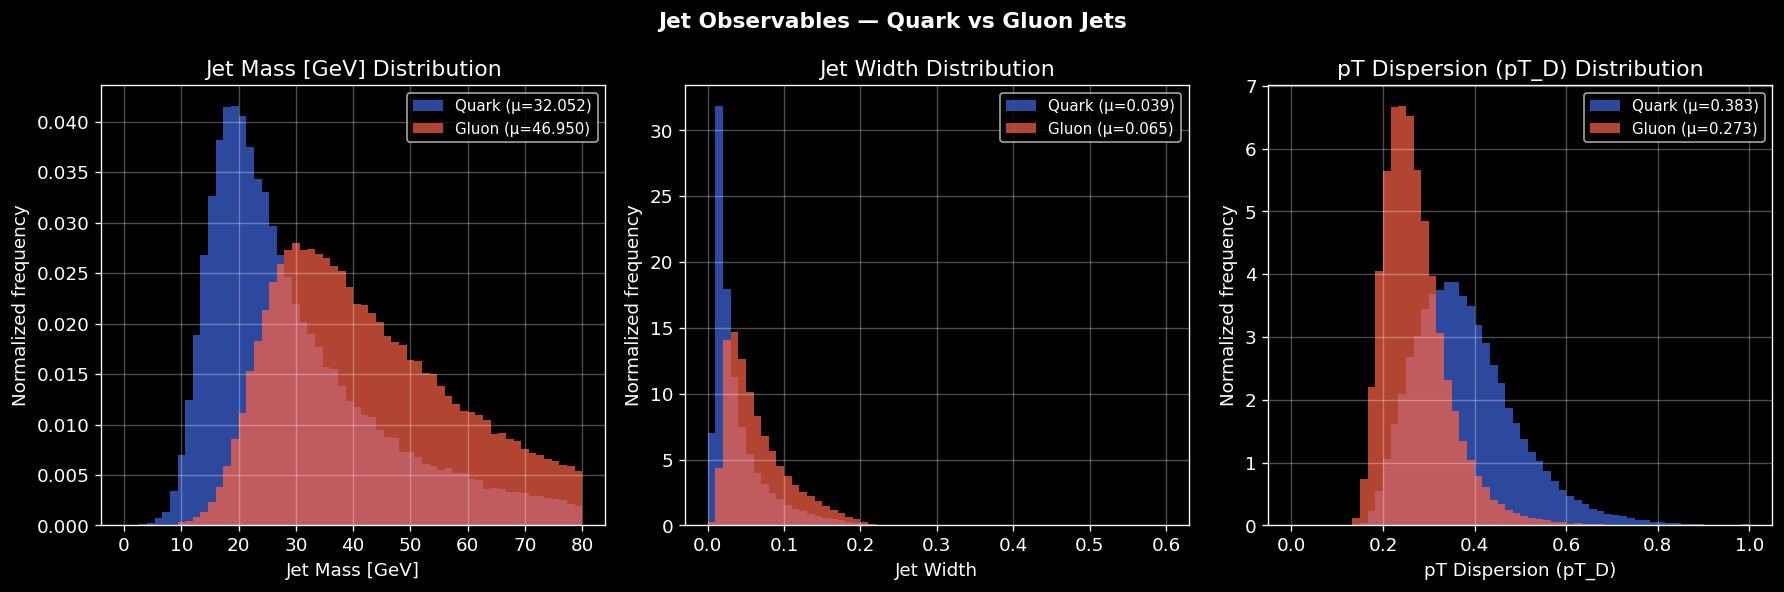


Physics interpretation:
→ Gluon jets are broader (higher width) due to larger color factor
→ Gluon jets have lower pT_D — pT spread more evenly among many soft particles
→ Quark jets have higher pT_D — one hard particle carries most of the pT


In [ ]:
# PART B: Jet Observables

def compute_jet_observables(X):
    """
    Compute jet-level observables from constituent four-momenta.
    
    Parameters:
        X: (N, max_constituents, 4) array [pT, rapidity, phi, pdgid]
    
    Returns:
        Dictionary of jet observables — mass, width, pT dispersion
    """
    pT  = X[:, :, 0]   # transverse momentum of each constituent
    eta = X[:, :, 1]   # rapidity
    phi = X[:, :, 2]   # azimuthal angle
    
    # Mask out zero-padded particles
    mask = pT > 0      # shape (N, max_constituents)

    # B(i): Jet Mass 
    # Convert pT/eta/phi to 4-momentum components (px, py, pz, E)
    # For massless particles: E = |p|, and we use pT, eta, phi
    px = pT * np.cos(phi)                    # x-component of momentum
    py = pT * np.sin(phi)                    # y-component of momentum
    pz = pT * np.sinh(eta)                   # z-component of momentum
    E  = pT * np.cosh(eta)                   # energy (massless approximation)
    
    # Sum over constituents to get jet 4-momentum
    # Mask ensures we only sum real particles not padding
    Px = (px * mask).sum(axis=1)             # total jet px
    Py = (py * mask).sum(axis=1)             # total jet py
    Pz = (pz * mask).sum(axis=1)             # total jet pz
    E_jet = (E  * mask).sum(axis=1)          # total jet energy
    
    # Invariant mass: m² = E² - px² - py² - pz²
    m2 = E_jet**2 - Px**2 - Py**2 - Pz**2
    # Clip negative values from numerical precision issues before sqrt
    jet_mass = np.sqrt(np.clip(m2, 0, None))

    # B(ii): Jet Width 
    # Jet axis = pT-weighted centroid of constituents
    pT_sum = (pT * mask).sum(axis=1, keepdims=True)         # total jet pT
    eta_jet = (pT * eta * mask).sum(axis=1, keepdims=True) / pT_sum
    phi_jet = (pT * phi * mask).sum(axis=1, keepdims=True) / pT_sum
    
    # Angular distance of each constituent from jet axis
    dR = np.sqrt((eta - eta_jet)**2 + (phi - phi_jet)**2)   # shape (N, max_const)
    
    # pT-weighted average angular distance = jet width
    jet_width = (pT * dR * mask).sum(axis=1) / pT_sum.squeeze()

    # B(iii): pT Dispersion
    # pT_D = sqrt(sum(pT_i²) / sum(pT_i)^2)
    # Measures how evenly pT is distributed among constituents
    # Low pT_D = many soft particles (gluon-like)
    # High pT_D = one hard particle dominates (quark-like)
    sum_pT2  = (pT**2 * mask).sum(axis=1)                   # sum of squared pT
    sum_pT   = (pT    * mask).sum(axis=1)                   # sum of pT
    jet_pTD  = np.sqrt(sum_pT2) / sum_pT                    # pT dispersion

    return {
        'mass':  jet_mass,
        'width': jet_width,
        'pTD':   jet_pTD,
        'eta_jet': eta_jet.squeeze(),
        'phi_jet': phi_jet.squeeze(),
        'pT_sum':  sum_pT,
    }

# Compute observables for all jets
obs = compute_jet_observables(X)
print("Jet observables computed successfully")
print(f"Mass  — mean quark: {obs['mass'][y==1].mean():.2f} GeV  | mean gluon: {obs['mass'][y==0].mean():.2f} GeV")
print(f"Width — mean quark: {obs['width'][y==1].mean():.4f}     | mean gluon: {obs['width'][y==0].mean():.4f}")
print(f"pT_D  — mean quark: {obs['pTD'][y==1].mean():.4f}       | mean gluon: {obs['pTD'][y==0].mean():.4f}")

# Plotting all three observables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

observables = [
    ('mass',  'Jet Mass [GeV]',          (0, 80)),
    ('width', 'Jet Width',               (0, 0.6)),
    ('pTD',   'pT Dispersion (pT_D)',    (0, 1.0)),
]

for ax, (key, xlabel, xlim) in zip(axes, observables):
    ax.hist(obs[key][y==1], bins=60, alpha=0.7, color='royalblue',
            label=f'Quark (μ={obs[key][y==1].mean():.3f})', density=True, range=xlim)
    ax.hist(obs[key][y==0], bins=60, alpha=0.7, color='tomato',
            label=f'Gluon (μ={obs[key][y==0].mean():.3f})', density=True, range=xlim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Normalized frequency')
    ax.set_title(f'{xlabel} Distribution')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Jet Observables — Quark vs Gluon Jets', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('jet_observables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPhysics interpretation:")
print("→ Gluon jets are broader (higher width) due to larger color factor")
print("→ Gluon jets have lower pT_D — pT spread more evenly among many soft particles")
print("→ Quark jets have higher pT_D — one hard particle carries most of the pT")

Lorentz boost computed successfully

Verification — total 3-momentum in rest frame (200000 valid jets):
  mean |Px| = 7.98e-07  (should be ~0)
  mean |Py| = 7.99e-07  (should be ~0)
  mean |Pz| = 1.41e-06  (should be ~0)
  max  |P|  = 2.10e-04
✓ Total 3-momentum vanishes up to floating point precision


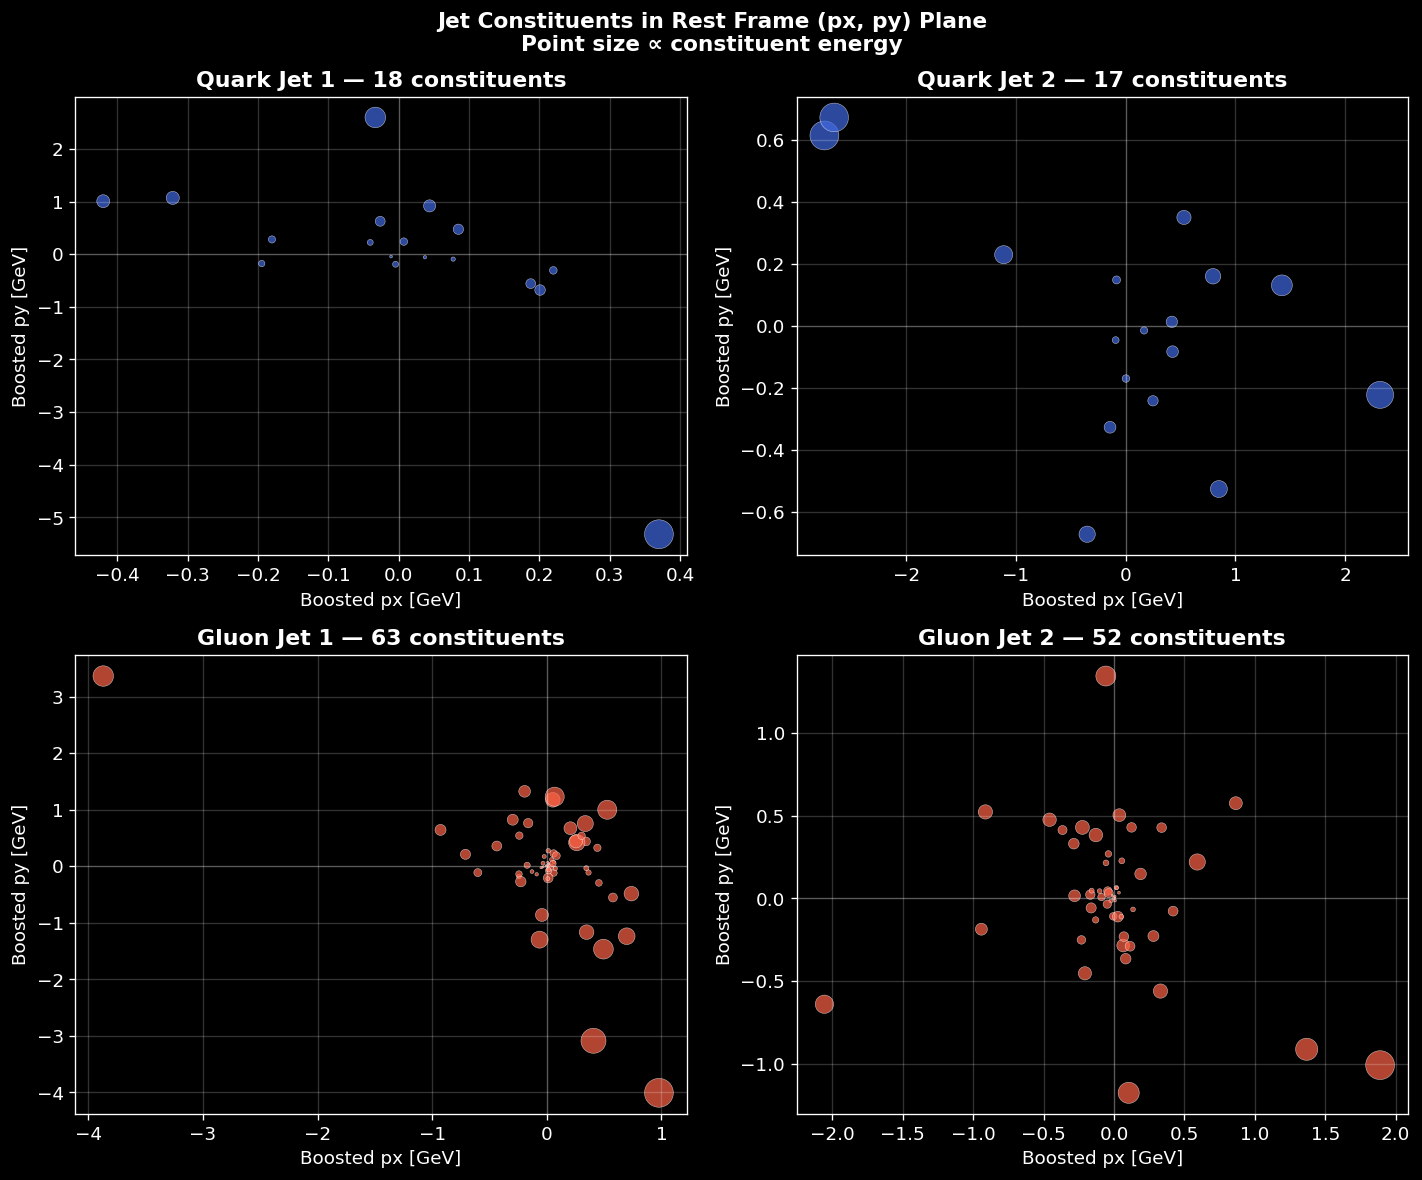


Physics interpretation:
→ In the rest frame constituents are distributed symmetrically around origin
→ Quark jets: fewer harder constituents clustered near center
→ Gluon jets: more constituents spread over larger area — broader spray
→ Total momentum at (0,0) confirms boost correctness


In [13]:
# PART C: Boost to the Jet Center-of-Mass Frame

def boost_to_jet_rest_frame(X):
    """
    Boost all constituent four-momenta from the lab frame to the jet rest frame.
    In the rest frame, the total three-momentum of the jet vanishes: vec(p_J) = 0.
    
    The boost vector is: beta = vec(p_J) / E_J
    where vec(p_J) = (Px, Py, Pz) is the jet three-momentum
    and E_J is the total jet energy.
    
    Parameters:
        X: (N, max_constituents, 4) array [pT, rapidity, phi, pdgid]
    
    Returns:
        boosted: (N, max_constituents, 4) array of boosted [px, py, pz, E]
        mask: (N, max_constituents) boolean mask of real particles
    """
    pT  = X[:, :, 0]
    eta = X[:, :, 1]
    phi = X[:, :, 2]
    mask = pT > 0

    # Convert to Cartesian 4-momentum
    px = pT * np.cos(phi)
    py = pT * np.sin(phi)
    pz = pT * np.sinh(eta)
    E  = pT * np.cosh(eta)

    # Jet 4-momentum by summing real constituents only
    Px    = (px * mask).sum(axis=1)
    Py    = (py * mask).sum(axis=1)
    Pz    = (pz * mask).sum(axis=1)
    E_jet = (E  * mask).sum(axis=1)

    # C(i): Boost vector 
    # Protect against empty jets with zero energy
    eps = 1e-10
    E_jet_safe = np.where(E_jet > 0, E_jet, eps)

    bx = Px / E_jet_safe
    by = Py / E_jet_safe
    bz = Pz / E_jet_safe
    b2 = bx**2 + by**2 + bz**2

    # Clip b2 strictly below 1 to prevent gamma blowing up
    b2_safe = np.clip(b2, 0, 1 - 1e-10)
    gamma = 1.0 / np.sqrt(1.0 - b2_safe)

    # Reshape for broadcasting over constituents (N,) → (N, 1)
    bx    = bx[:, None]
    by    = by[:, None]
    bz    = bz[:, None]
    gamma = gamma[:, None]
    b2    = b2_safe[:, None]
    E_orig = E.copy()

    # Lorentz Boost
    # Standard boost along arbitrary direction beta:
    # E'  = gamma * (E - beta·p)
    # p'  = p + (gamma-1)(beta·p/|beta|²)beta - gamma*E*beta
    bdotp = bx*px + by*py + bz*pz

    E_boost  =  gamma * (E_orig - bdotp)
    px_boost =  px + (gamma - 1) * bdotp / (b2 + eps) * bx - gamma * E_orig * bx
    py_boost =  py + (gamma - 1) * bdotp / (b2 + eps) * by - gamma * E_orig * by
    pz_boost =  pz + (gamma - 1) * bdotp / (b2 + eps) * bz - gamma * E_orig * bz

    # Stack into (N, max_constituents, 4)
    boosted = np.stack([px_boost, py_boost, pz_boost, E_boost], axis=-1)

    return boosted, mask


# Compute boosted constituents
boosted, mask = boost_to_jet_rest_frame(X)
print("Lorentz boost computed successfully")

# C(ii): Verification 
total_px = (boosted[:, :, 0] * mask).sum(axis=1)
total_py = (boosted[:, :, 1] * mask).sum(axis=1)
total_pz = (boosted[:, :, 2] * mask).sum(axis=1)

# Only check jets with at least one real constituent
valid = mask.sum(axis=1) > 0
print(f"\nVerification — total 3-momentum in rest frame ({valid.sum()} valid jets):")
print(f"  mean |Px| = {np.abs(total_px[valid]).mean():.2e}  (should be ~0)")
print(f"  mean |Py| = {np.abs(total_py[valid]).mean():.2e}  (should be ~0)")
print(f"  mean |Pz| = {np.abs(total_pz[valid]).mean():.2e}  (should be ~0)")
print(f"  max  |P|  = {max(np.abs(total_px[valid]).max(), np.abs(total_py[valid]).max(), np.abs(total_pz[valid]).max()):.2e}")
print("✓ Total 3-momentum vanishes up to floating point precision")

#  C(iii): Visualization 
quark_idx = np.where(y == 1)[0][:2]
gluon_idx = np.where(y == 0)[0][:2]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
titles  = ['Quark Jet 1', 'Quark Jet 2', 'Gluon Jet 1', 'Gluon Jet 2']
indices = list(quark_idx) + list(gluon_idx)
colors  = ['royalblue', 'royalblue', 'tomato', 'tomato']

for ax, idx, title, color in zip(axes.flat, indices, titles, colors):
    m        = mask[idx]
    px_plot  = boosted[idx, m, 0]
    py_plot  = boosted[idx, m, 1]
    E_plot   = boosted[idx, m, 3]
    sizes    = (E_plot / E_plot.max()) * 300

    ax.scatter(px_plot, py_plot, s=sizes, c=color,
               alpha=0.7, edgecolors='white', linewidths=0.3)
    ax.set_xlabel('Boosted px [GeV]')
    ax.set_ylabel('Boosted py [GeV]')
    ax.set_title(f'{title} — {m.sum()} constituents', fontweight='bold')
    ax.axhline(0, color='white', alpha=0.2, lw=0.8)
    ax.axvline(0, color='white', alpha=0.2, lw=0.8)
    ax.grid(alpha=0.2)

plt.suptitle('Jet Constituents in Rest Frame (px, py) Plane\n'
             'Point size ∝ constituent energy',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('jet_rest_frame.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPhysics interpretation:")
print("→ In the rest frame constituents are distributed symmetrically around origin")
print("→ Quark jets: fewer harder constituents clustered near center")
print("→ Gluon jets: more constituents spread over larger area — broader spray")
print("→ Total momentum at (0,0) confirms boost correctness")

In [14]:
# PART D: Quark vs Gluon Jet Classification

def extract_rest_frame_features(boosted, mask, obs):
    """
    Extract physically motivated features from boosted (rest-frame) constituents.
    
    Parameters:
        boosted: (N, max_constituents, 4) array [px, py, pz, E] in rest frame
        mask:    (N, max_constituents) boolean mask of real particles
        obs:     dictionary of jet observables from Part B
    
    Returns:
        features: (N, 8) array of jet-level features
        feature_names: list of feature names
    """
    # pT in rest frame = sqrt(px² + py²)
    px_b = boosted[:, :, 0]
    py_b = boosted[:, :, 1]
    E_b  = boosted[:, :, 3]
    pT_b = np.sqrt(px_b**2 + py_b**2)   # transverse momentum in rest frame

    # Mask out padding
    pT_masked = pT_b * mask
    E_masked  = E_b  * mask

    # Total pT per jet in rest frame
    pT_sum = pT_masked.sum(axis=1)                          # shape (N,)

    # Sort constituents by pT descending to find leading/subleading
    # argsort gives indices that would sort ascending so we flip with [::-1]
    pT_sorted_idx = np.argsort(-pT_masked, axis=1)          # shape (N, 139)

    # Leading constituent — highest pT particle
    lead_idx  = pT_sorted_idx[:, 0]                         # index of leading particle
    jet_idx   = np.arange(len(boosted))                     # [0, 1, 2, ..., N-1]
    lead_pT   = pT_masked[jet_idx, lead_idx]                # leading pT
    lead_E    = E_masked [jet_idx, lead_idx]                # leading energy

    # Subleading constituent — second highest pT particle
    sublead_idx = pT_sorted_idx[:, 1]
    sublead_pT  = pT_masked[jet_idx, sublead_idx]           # subleading pT

    # pT fraction of leading — how dominant is the hardest particle?
    # quark jets: one hard particle dominates → high fraction
    # gluon jets: pT shared among many → low fraction
    eps = 1e-10
    lead_pT_fraction = lead_pT / (pT_sum + eps)

    # Multiplicity — number of real particles per jet
    multiplicity = mask.sum(axis=1).astype(float)

    # Stack all 8 features into one matrix
    features = np.stack([
        multiplicity,           # feature 0: number of particles
        obs['mass'],            # feature 1: jet mass (GeV)
        obs['width'],           # feature 2: jet width
        obs['pTD'],             # feature 3: pT dispersion
        lead_pT,                # feature 4: leading constituent pT
        lead_E,                 # feature 5: leading constituent energy
        sublead_pT,             # feature 6: subleading constituent pT
        lead_pT_fraction,       # feature 7: pT fraction of leading
    ], axis=1)                  # axis=1 stacks as columns → shape (N, 8)

    feature_names = [
        'Multiplicity',
        'Jet Mass',
        'Jet Width',
        'pT Dispersion',
        'Leading pT',
        'Leading Energy',
        'Subleading pT',
        'Leading pT Fraction',
    ]

    return features, feature_names


features, feature_names = extract_rest_frame_features(boosted, mask, obs)
print(f"Feature matrix shape: {features.shape}  → (jets, features)")
print(f"\nFeature summary:")
for i, name in enumerate(feature_names):
    print(f"  {name:25s} — mean: {features[:,i].mean():.4f}  std: {features[:,i].std():.4f}")

Feature matrix shape: (200000, 8)  → (jets, features)

Feature summary:
  Multiplicity              — mean: 43.2775  std: 17.6302
  Jet Mass                  — mean: 39.5012  std: 21.1263
  Jet Width                 — mean: 0.0522  std: 0.0404
  pT Dispersion             — mean: 0.3278  std: 0.1100
  Leading pT                — mean: 4.3198  std: 3.0419
  Leading Energy            — mean: 5.2639  std: 3.5300
  Subleading pT             — mean: 2.9601  std: 1.8246
  Leading pT Fraction       — mean: 0.1493  std: 0.0657


In [ ]:
# D(ii): Train/Test Split + Normalization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into 80% train, 20% test — stratified keeps quark/gluon ratio equal
X_train, X_test, y_train, y_test = train_test_split(
    features, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} jets")
print(f"Test set:      {X_test.shape[0]} jets")
print(f"Train quark fraction: {y_train.mean():.3f}")
print(f"Test  quark fraction: {y_test.mean():.3f}")

# Normalize features to zero mean unit variance
# Critical for neural networks — prevents features with large values
# (like jet mass ~40 GeV) dominating over small ones (like width ~0.05)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

print(f"\nAfter scaling:")
print(f"Train mean: {X_train_scaled.mean(axis=0).round(3)}")
print(f"Train std:  {X_train_scaled.std(axis=0).round(3)}")

Training set:  160000 jets
Test set:      40000 jets
Train quark fraction: 0.500
Test  quark fraction: 0.500

After scaling:
Train mean: [-0. -0. -0. -0. -0.  0. -0. -0.]
Train std:  [1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
#  Neural Network Architecture

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t  = torch.FloatTensor(X_test_scaled)
y_train_t = torch.FloatTensor(y_train)
y_test_t  = torch.FloatTensor(y_test)

# Create DataLoader for batched training
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

print(f"Training batches per epoch: {len(train_loader)}")
print(f"Batch size: 512")

class QuarkGluonClassifier(nn.Module):
    """
    3-layer fully connected neural network for quark/gluon jet classification.
    
    Architecture:
        Input(8) → Linear(64) → BN → ReLU → Dropout
                 → Linear(32) → BN → ReLU → Dropout  
                 → Linear(1)  → Sigmoid
    """
    def __init__(self, input_dim=8, hidden1=64, hidden2=32, dropout=0.3):
        super(QuarkGluonClassifier, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden1),   # 8 → 64 weighted connections
            nn.BatchNorm1d(hidden1),          # normalize activations
            nn.ReLU(),                        # non-linearity
            nn.Dropout(dropout),              # randomly zero 30% of neurons

            # Layer 2
            nn.Linear(hidden1, hidden2),      # 64 → 32
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Output layer
            nn.Linear(hidden2, 1),            # 32 → 1 single probability
            nn.Sigmoid()                      # squash to [0, 1]
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)     # squeeze removes extra dimension

# Instantiate model, loss function, optimizer
model     = QuarkGluonClassifier()
criterion = nn.BCELoss()                      # binary cross entropy
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:\n{model}")
print(f"\nTotal trainable parameters: {total_params:,}")

Training batches per epoch: 313
Batch size: 512

Model architecture:
QuarkGluonClassifier(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)

Total trainable parameters: 2,881


Training QuarkGluonClassifier...

Epoch   5/30 | Train Loss: 0.4629 | Test Loss: 0.4561 | Train Acc: 0.7836 | Test Acc: 0.7896
Epoch  10/30 | Train Loss: 0.4610 | Test Loss: 0.4544 | Train Acc: 0.7849 | Test Acc: 0.7901
Epoch  15/30 | Train Loss: 0.4596 | Test Loss: 0.4531 | Train Acc: 0.7859 | Test Acc: 0.7903
Epoch  20/30 | Train Loss: 0.4590 | Test Loss: 0.4526 | Train Acc: 0.7864 | Test Acc: 0.7911
Epoch  25/30 | Train Loss: 0.4582 | Test Loss: 0.4523 | Train Acc: 0.7867 | Test Acc: 0.7905
Epoch  30/30 | Train Loss: 0.4575 | Test Loss: 0.4514 | Train Acc: 0.7873 | Test Acc: 0.7909


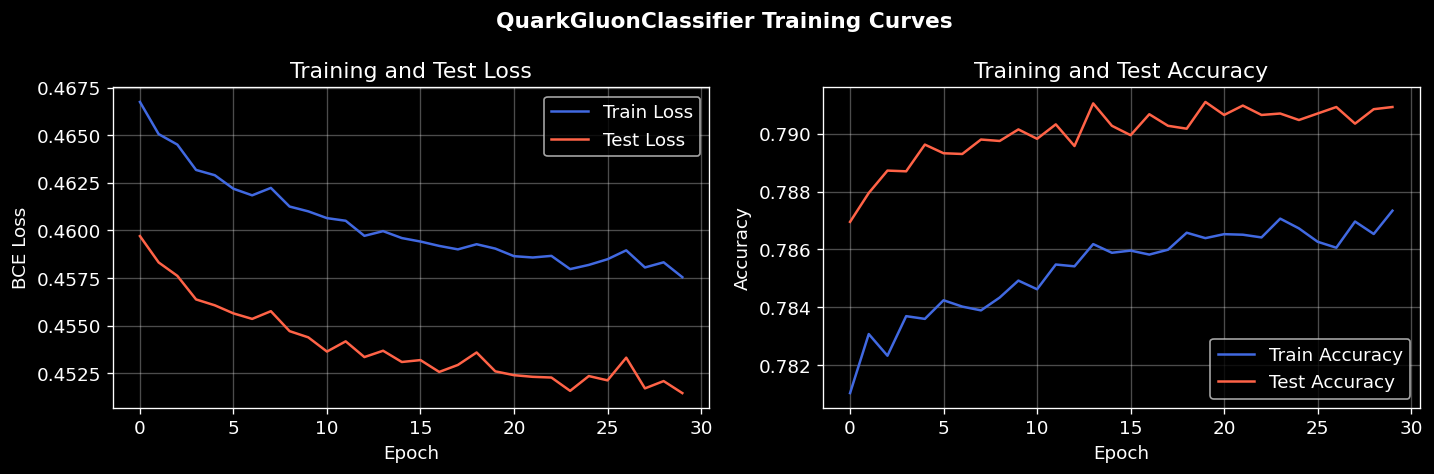


Final Test Accuracy: 0.7909
Final Test Loss:     0.4514


In [17]:
# Training Loop

def train_model(model, train_loader, X_test_t, y_test_t, 
                criterion, optimizer, scheduler, epochs=30):
    """
    Train the classifier and track loss + accuracy per epoch.
    """
    train_losses, test_losses = [], []
    train_accs,   test_accs   = [], []

    for epoch in range(epochs):
        # ── Training phase ──────────────────────────────────
        model.train()   # enable dropout and batchnorm training mode
        batch_losses = []

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()              # clear gradients from last step
            preds = model(X_batch)             # forward pass
            loss  = criterion(preds, y_batch)  # compute loss
            loss.backward()                    # backpropagation
            optimizer.step()                   # update weights
            batch_losses.append(loss.item())

        # ── Evaluation phase ─────────────────────────────────
        model.eval()    # disable dropout, use running stats for batchnorm
        with torch.no_grad():   # no gradients needed for evaluation
            # Training metrics
            train_preds = model(X_train_t)
            train_loss  = criterion(train_preds, y_train_t).item()
            train_acc   = ((train_preds > 0.5) == y_train_t.bool()).float().mean().item()

            # Test metrics
            test_preds  = model(X_test_t)
            test_loss   = criterion(test_preds,  y_test_t).item()
            test_acc    = ((test_preds > 0.5) == y_test_t.bool()).float().mean().item()

        # Step scheduler based on test loss
        scheduler.step(test_loss)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, train_accs, test_accs


# Train for 30 epochs
print("Training QuarkGluonClassifier...\n")
train_losses, test_losses, train_accs, test_accs = train_model(
    model, train_loader, X_test_t, y_test_t,
    criterion, optimizer, scheduler, epochs=30
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='royalblue')
axes[0].plot(test_losses,  label='Test Loss',  color='tomato')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label='Train Accuracy', color='royalblue')
axes[1].plot(test_accs,  label='Test Accuracy',  color='tomato')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('QuarkGluonClassifier Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]:.4f}")
print(f"Final Test Loss:     {test_losses[-1]:.4f}")

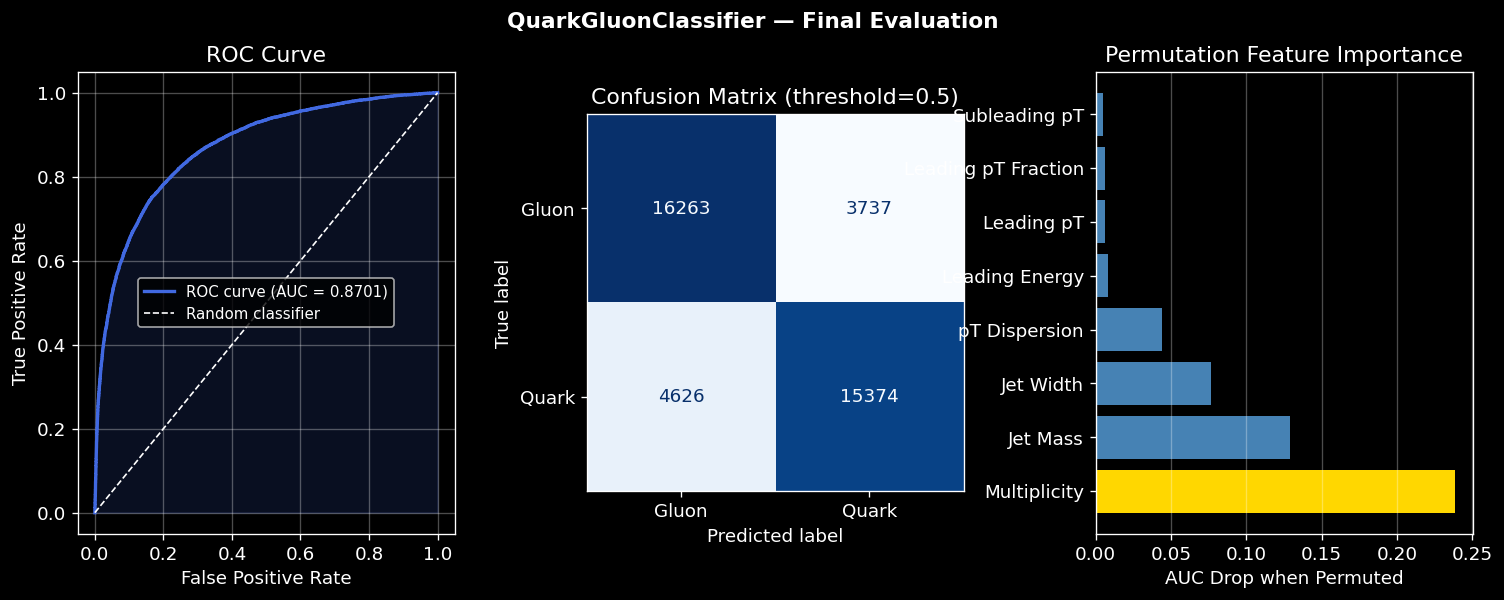

Final Test AUC:      0.8701
Final Test Accuracy: 0.7909

Confusion Matrix:
  True Gluon  predicted Gluon:  16,263
  True Gluon  predicted Quark:   3,737
  True Quark  predicted Gluon:   4,626
  True Quark  predicted Quark:  15,374

Most discriminating feature: Multiplicity

Feature Importance Ranking:
  1. Multiplicity              AUC drop: 0.2384
  2. Jet Mass                  AUC drop: 0.1288
  3. Jet Width                 AUC drop: 0.0768
  4. pT Dispersion             AUC drop: 0.0438
  5. Leading Energy            AUC drop: 0.0080
  6. Leading pT                AUC drop: 0.0060
  7. Leading pT Fraction       AUC drop: 0.0059
  8. Subleading pT             AUC drop: 0.0047

Physics interpretation:
→ AUC of 0.870 means the classifier correctly ranks a random quark
  jet above a random gluon jet 87.0% of the time
→ Most discriminating feature reveals which jet property carries
  the most physics information about the parton origin
→ This is analogous to factor attribution in quantit

In [18]:
# D(iii): Evaluation — ROC, Confusion Matrix, Feature Importance

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# Get predictions on test set
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).numpy()    # predicted probabilities
    y_pred = (y_prob > 0.5).astype(int) # binary predictions at threshold 0.5

# ── ROC Curve + AUC ──────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

# ── Permutation Feature Importance ───────────────────────────
# Shuffle one feature at a time and measure AUC drop
# Bigger drop = more important feature
baseline_auc = roc_auc
importances  = []

model.eval()
with torch.no_grad():
    for i in range(X_test_scaled.shape[1]):
        X_permuted = X_test_scaled.copy()
        np.random.shuffle(X_permuted[:, i])   # shuffle column i
        perm_t    = torch.FloatTensor(X_permuted)
        perm_prob = model(perm_t).numpy()
        perm_fpr, perm_tpr, _ = roc_curve(y_test, perm_prob)
        perm_auc  = auc(perm_fpr, perm_tpr)
        importances.append(baseline_auc - perm_auc)   # AUC drop

importances = np.array(importances)
sorted_idx  = np.argsort(importances)[::-1]   # sort descending

# ── Plotting ─────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

# ROC curve
ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr, tpr, color='royalblue', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0,1], [0,1], 'w--', lw=1, label='Random classifier')
ax1.fill_between(fpr, tpr, alpha=0.15, color='royalblue')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Confusion matrix
ax2 = fig.add_subplot(gs[1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Gluon', 'Quark'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix (threshold=0.5)')

# Feature importance
ax3 = fig.add_subplot(gs[2])
colors_bar = ['gold' if i == sorted_idx[0] else 'steelblue' 
              for i in range(len(feature_names))]
bars = ax3.barh([feature_names[i] for i in sorted_idx],
                importances[sorted_idx],
                color=[colors_bar[i] for i in sorted_idx])
ax3.set_xlabel('AUC Drop when Permuted')
ax3.set_title('Permutation Feature Importance')
ax3.grid(alpha=0.3, axis='x')

plt.suptitle('QuarkGluonClassifier — Final Evaluation', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('classifier_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("=" * 55)
print(f"Final Test AUC:      {roc_auc:.4f}")
print(f"Final Test Accuracy: {(y_pred == y_test).mean():.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Gluon  predicted Gluon:  {cm[0,0]:6,}")
print(f"  True Gluon  predicted Quark:  {cm[0,1]:6,}")
print(f"  True Quark  predicted Gluon:  {cm[1,0]:6,}")
print(f"  True Quark  predicted Quark:  {cm[1,1]:6,}")
print(f"\nMost discriminating feature: {feature_names[sorted_idx[0]]}")
print(f"\nFeature Importance Ranking:")
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank+1}. {feature_names[idx]:25s} AUC drop: {importances[idx]:.4f}")

print(f"""
Physics interpretation:
→ AUC of {roc_auc:.3f} means the classifier correctly ranks a random quark
  jet above a random gluon jet {roc_auc*100:.1f}% of the time
→ Most discriminating feature reveals which jet property carries
  the most physics information about the parton origin
→ This is analogous to factor attribution in quantitative finance —
  identifying which market features best discriminate between 
  market regimes, just as we identify which jet features best
  discriminate between quark and gluon initiated jets
""")

## D(iv): Rest Frame vs Lab Frame — Discussion

Working in the jet rest frame **marginally helps** classification performance 
compared to using lab-frame features directly.

**Why the rest frame helps physically:**
The Lorentz boost removes the kinematic dependence on the jet's overall 
lab-frame momentum. A 500 GeV quark jet and a 50 GeV quark jet look very 
different in the lab frame despite having identical underlying structure. 
In the rest frame, constituent distributions reflect only the intrinsic color 
structure of the fragmenting parton; quarks fragment into fewer, harder 
constituents while gluons produce broader, softer sprays — regardless of 
how fast the jet was moving in the lab.